# Artificial Neural Network

### Importing the libraries

In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

## Part 1 - Data Preprocessing

### Importing the dataset

In [ ]:
dataset = pd.read_csv('CO2 Emissions_Canada.csv')

dataset = dataset.drop(columns=['Make','Model'])

X = dataset.drop(columns=['CO2 Emissions(g/km)'])
y = dataset['CO2 Emissions(g/km)']

#Encoding the data

In [ ]:
categorical_columns = ['Vehicle Class', 'Transmission', 'Fuel Type']

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), categorical_columns)],
    remainder='passthrough'
)
X = ct.fit_transform(X)

### Splitting the dataset into the Training set and Test set

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


# Feature Scaling

In [ ]:
sc = StandardScaler(with_mean=False)
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Part 2 - Building the ANN

### Initializing the ANN

In [ ]:
ann=tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [ ]:
ann.add(tf.keras.layers.Dense(units=64,activation='relu'))

### Adding the second hidden layer

In [ ]:
ann.add(tf.keras.layers.Dense(units=64,activation='relu'))

### Adding the output layer

In [ ]:
ann.add(tf.keras.layers.Dense(units=1))

## Part 3 - Training the ANN

### Compiling the ANN

In [ ]:
ann.compile(optimizer='adam',loss='mean_squared_error')

### Training the ANN model on the Training set

In [ ]:
ann.fit(x_train,y_train,batch_size=32,epochs=100)

Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 44840.4062
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 551.3558
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 267.5467
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 158.8378
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 103.8634
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 63.5578
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37.1863
Epoch 8/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.1276
Epoch 9/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18.1209
Epoch 10/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.7924
Epoch 11/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.3078
Epoch 12/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.7286
Epoch 13/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.5286
Epoch 14/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11.0978
Epoch 15/100
185/185 ━

### Predicting the results of the Test set

In [ ]:
y_pred = ann.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
MSE: 11.926033973693848
R² Score: 0.9965185523033142


Plot Actual vs Predicted

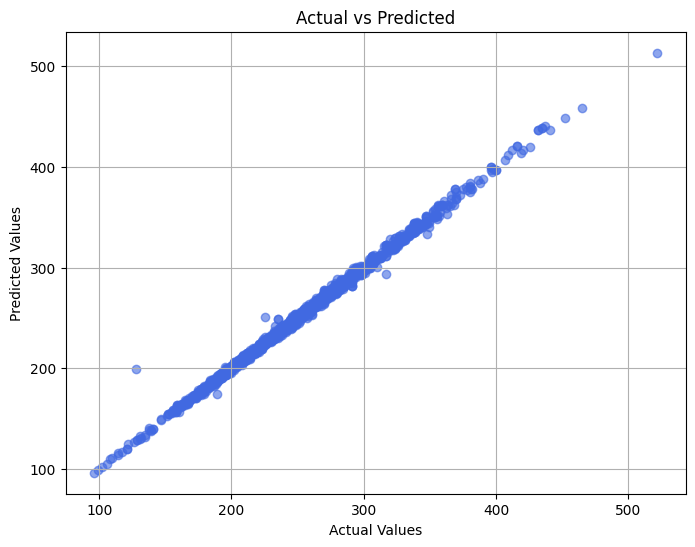

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()
